












































# Homework 03: Model Selection, Bayesian Linear Regression and Gaussian Processes 
**Submission Deadline: June 19, 2026, Friday, 9:30**

---

> **Machine Learning - Foundations and Algorithms** in Summer Semester 2026
>
> - Prof. Gerhard Neumann
> - Instructors for this exercise: Florian Seligmann (florian.seligmann@kit.edu), and Emiliyan Gospodinov (emiliyan.gospodinov@kit.edu)
> 
> ⚠️ For general questions about the exercises, please post in the Ilias forum so we can answer them once for all students. Only use email for individual questions whose answers are not relevant to all students.

---

## Homework Info

This homework is about model selection and probabilistic regression. You will compare hold-out validation and k-fold cross-validation for polynomial regression, implement Bayesian Linear Regression (BLR) posterior and predictive distributions, and work with Gaussian Process (GP) regression using a Gaussian kernel.

The exercise also includes short multiple-choice questions to check your intuition about selected models, cross-validation partition sizes, out-of-distribution predictions, the relation between BLR and Ridge Regression, and function sampling from GPs.

This homework contains coding tasks, visualization/intuition cells, and multiple-choice tasks. **Only the coding and multiple-choice tasks will be graded.** The visualization and explanatory cells are included to help you understand the methods, prepare for the exam, and support the discussion in the exercise session.


## Group Submission

- The exercise sheets can be submitted in **groups of up to 3 students**.
- **Each person in the group must upload the edited notebook to Ilias**. It is not sufficient if only one person from the group does this. If you forgot to upload but at least on other group member upholds his solution, you will receive 2/3 of the points the **first** time this happens, and zero points if it **happens again**.
- **The submission deadline is strict**. Late submissions receive zero points. **We do not accept submissions via e-mail**. 
- It is possible to join a new group during the semester if your own group dissolves early. Each group must upload their own solution, and we will check submissions for duplicates.
- You can use the team building forum (https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:lz:5y&cmdClass=ilBookingObjectGUI&ref_id=2930523) to team up. If you already have group members or want to submit alone, you do not need to use the forum.


Groups are automatically recorded for each exercise, so **please enter the u-identifiers of your group members in the *next* cell.** If your group consists of only 2 students or if you are submitting alone, leave the remaining fields empty.

Here is an **example** for a group consisting of uabcd and uefgh:

_U-identifiers of group members:_

_Member 1: uabcd_

_Member 2: uefgh_

_Member 3:_

Enter your group members in the *next* cell!

U-identifiers of group members:

Member 1: uiwkc

Member 2: urelg

Member 3:

## Auto-grading

We use an auto-grading system that automatically analyzes your submitted Jupyter Notebook and checks your graded answers with visible and hidden tests. The hidden tests determine the final points you receive for the coding and multiple-choice tasks.

To ensure auto-grading works smoothly, please note the following:

- The notebook must have the filename `ex_03_model_selection_bayesian_linear_regression_gaussian_processes.ipynb`.
- **Upload only the Jupyter Notebook** on Ilias as a single file, not as a zip archive. **Do not include any additional files**.
- Before submitting, restart the kernel and run the notebook from start to finish. It must run without errors.
- Enter your solutions only in the designated answer/code cells.
- Do not delete, add, reorder, or rename cells or variables that are provided by the notebook. The auto-grader expects the original notebook structure.
- The visible asserts in the notebook are included to help you catch common mistakes. Passing them is necessary, but not sufficient, for full points because additional hidden tests are used for grading.

**If you fail to comply with these rules, your submission may not be graded and you may receive no points for this exercise.**


In this exercise, we are going to explore different model selection methods. Specifically, we are considering the Hold-out methods and cross-validation.

In [1]:
##### DO NOT CHANGE #####
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

##### DO NOT CHANGE #####

Let's start by creating a noisy toy dataset from an unknown smooth nonlinear function. We will use polynomial regression models of different degrees to approximate it.


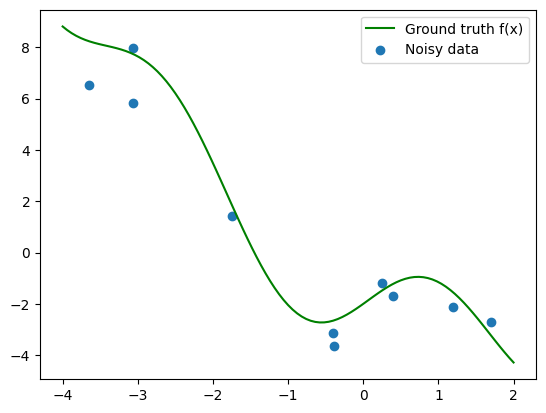

In [2]:
##### DO NOT CHANGE #####
np.random.seed(42)
x = np.linspace(-4, 2, 101)  # for plotting


def target_function(x_values: np.ndarray) -> np.ndarray:
    """Smooth nonlinear ground-truth function used to generate the toy data."""
    return 0.4 * x_values**2 - 1.5 * x_values + 2.0 * np.sin(1.8 * x_values) - 2.0


y_gt = target_function(x)

n_data = 10  # create 10 data points
x_data = np.random.uniform(-4, 2, n_data)
y_data_gt = target_function(x_data)
y_data = y_data_gt + 1 * np.random.randn(n_data)

plt.plot(x, y_gt, color='g', label="Ground truth f(x)")
plt.scatter(x_data, y_data, label="Noisy data")
plt.legend()


##### DO NOT CHANGE #####

## Exercise 1: Model Selection for Polynomial Regression (9 Points)
In this exercise, you will use two validation methods to select the optimal polynomial degree for a polynomial regression model: Hold-out validation and cross-validation.
Your goal is to determine the optimal model complexity by minimizing the validation mean squared error (MSE).

### Task 1.1: Implement Hold-Out Model Selection (3 Points)
The code below splits the data into training and validation sets, fits polynomial models of different orders, computes training and validation MSEs, and selects the model order with the lowest validation MSE.

Your task:
- For each polynomial degree, fit the weights on on the training split `D_T`, evaluate the model on the validation split `D_V`, and compute validation and training mean squared errors (MSEs).
- In the end, automaticall select the polynomial degree with the lowest validation MSE.

Use `np.polyfit` to compute the weights for a given degree. `polyfit` takes the raw, untransformed data (do not apply feature transformations!) and the degree of the polynomial, and returns the optimal coefficients for a polynomial fit (i.e., the polynomial linear regression weights). Similarly, `polyval` takes these weights and untransformed data and evaluates the polynomial. Check out the numpy documentation for more details.

**Important**: If you do not use `polyfit` and `polyval`, we cannot guarantee that the automatic tests will work on your solution. Even if your solution would be correct, numerical differences might change the result in significant ways.

Best model order: 1


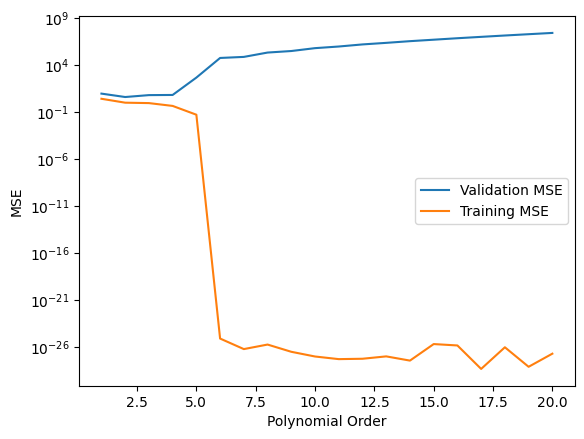

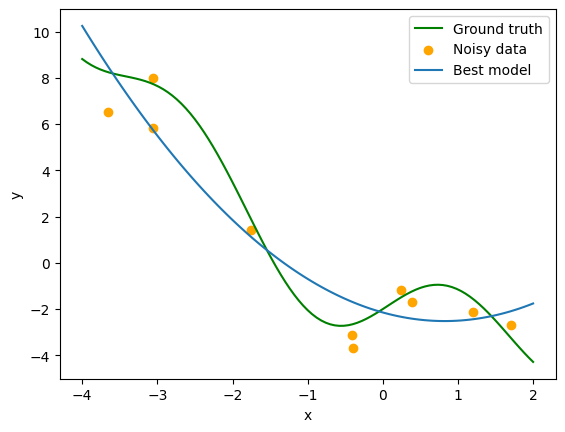

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Assume the following data is provided:
# x_data, y_data: arrays containing the input data points and corresponding noisy outputs
# x: array of points for plotting the ground truth and best model
# y_gt: array of ground truth values corresponding to x

M = 20  # Maximum order of polynomials to train
models = np.arange(1, M+1)
MSEs = []
mse_trains = []
p_best = None

split = 0.7  # Proportion of data to use for training
n_data = len(x_data)
split_ind = int(split * n_data)

# 1: Split into training and validation sets
np.random.seed(42)
ind = np.random.choice(n_data, n_data, replace=False)  # Shuffle data indices
ind_train = ind[:split_ind]
ind_val = ind[split_ind:]
D_T = {"x": x_data[ind_train], "y": y_data[ind_train]}  # Training data
D_V = {"x": x_data[ind_val], "y": y_data[ind_val]}  # Validation data

# Loop through polynomial orders and train models
for m in models:
    # 2: Train on training data (you should use np.polyfit)
    # TODO Compute the optimal weights for degree m using np.polyfit and write them to p
    p = np.polyfit(D_T.get("x"), D_T.get("y"), m)
    # YOUR CODE HERE
    
    # 3: Evaluate on validation data (you should use np.polyval)
    # TODO Compute the validation MSE with np.polyval
    mse_val = None
    # YOUR CODE HERE
    y_pred_val = np.polyval(p, D_V.get("x"))
    sqared_errors_val = (y_pred_val - D_V.get("y")) ** 2
    mse_val = np.mean(sqared_errors_val)
    MSEs.append(mse_val)
 
    # 4: Compute MSE on training data for comparison
    # TODO Compute the training MSE with np.polyval
    mse_train = None
    # YOUR CODE HERE
    y_pred_train = np.polyval(p, D_T.get("x"))
    sqared_errors_train = (y_pred_train - D_T.get("y")) ** 2
    mse_train = np.mean(sqared_errors_train)
    mse_trains.append(mse_train)

    # Log parameters of the best model order
    if mse_val <= np.min(MSEs):
        p_best = p

# 5: Pick model with best validation loss
# TODO The next line should select the model from `models` with the lowest validation error and write it to `m_star_hold_out`
m_star_hold_out = None
# YOUR CODE HERE
m_star_hold_out = MSEs.index(np.min(MSEs))
print("Best model order: {}".format(m_star_hold_out))
##########################

# Plotting MSE for training and validation sets
plt.figure()
plt.semilogy(models, MSEs, label="Validation MSE")
plt.semilogy(models, mse_trains, label="Training MSE")
plt.xlabel("Polynomial Order")
plt.ylabel("MSE")
plt.legend()

# Plotting the ground truth, data points, and best model
plt.figure()
plt.plot(x, y_gt, color='g', label="Ground truth")
plt.scatter(x_data, y_data, color='orange', label="Noisy data")
f_hat = np.polyval(p_best, x)
plt.plot(x, f_hat, label="Best model")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [25]:
##### DO NOT CHANGE #####
# ID: test_task_1_1 - possible points: 3

# There should be one MSE per model, and all MSEs must be non-negative
assert len(MSEs) == M
assert None not in MSEs
assert np.all(np.isfinite(MSEs))
assert np.all(np.asarray(MSEs) >= 0.0)

assert len(mse_trains) == M
assert None not in mse_trains
assert np.all(np.isfinite(mse_trains))
assert np.all(np.asarray(mse_trains) >= 0.0)

# m_star must be an integer
assert m_star_hold_out is not None
assert np.issubdtype(type(m_star_hold_out), np.integer)
assert m_star_hold_out in models

assert p_best is not None




##### DO NOT CHANGE #####

### Task 1.2: Interpreting the Selected Model (1 Point)

The hold-out validation above selects the polynomial degree with the lowest validation MSE among the tested candidate models. Does this mean that the selected model is necessarily a good approximation of the true data-generating function?

- a) Yes. Since the validation set was not used for fitting, the selected model is guaranteed to have the lowest expected error on future data.
- b) Yes. A low validation MSE implies that the selected polynomial will also extrapolate reliably outside the observed input range.
- c) No. It is only the best model among the tested candidates for this particular noisy train/validation split, and it may still generalize poorly or extrapolate badly.
- d) No. Validation MSE can only be used to compare training errors, not to select model complexity.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_1_2` variable.


In [26]:
answer_1_2 = "c"

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_2 - possible points: 1

assert answer_1_2 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

### Task 1.3: Implement k-Fold Cross-Validation (4 Points)
Now, we turn to k-fold cross-validation.
In the code below, we first shuffle the data using `np.random.choice` and then iterate over `k` partitions.

You need to implement two things for each index `k_`:
- Compute the indices for the training and validation splits. If `k_ == 0`, the first `n_val_data` indices from `rand_ind` should form the validation split `ind_val`, and the remaining indices are the training split `ind_train`. For `k_ == 1`, the second `n_val_data` indices form the validation split, and all remaining indices are the training data, and so on. You may find `np.roll` to be useful.
- For each split, fit the polynomial, and compute the training and valiation MSE. As in exercise 1.1, make sure to use `np.polyfit` and `np.polyval`!

In [45]:
def k_fold_cv(x, y, m, k):
    """
    k-fold cross validation method
    :param x: samples
    :param y: targets
    :param m: model order
    :param k: number of partitions
    :return mean MSE of test and training set
    """
    n_data = y.size
    if k > n_data:
        k = n_data

    MSEs_test = []
    MSEs_train = []
    
    n_val_data = n_data // k  # number of data points in each validation split
    rand_ind = np.random.choice(n_data, n_data, replace=False)  # random indices in [1, n] to shuffle data
    
    # loop over partitions
    for k_ in range(k):

        # 1: Split the indices in rand_ind into a training and validation dataset
        # TODO Compute indices for the validation and training data for the k_-th partition according to the split strategy described above
        ind_val = None # indices for validation data
        ind_train = None # indices for train data

        # YOUR CODE HERE

        start = k_ * n_val_data
        end = (k_ + 1) * n_val_data
        ind_val = rand_ind[start:end]
        ind_train = np.concatenate((rand_ind[:start], rand_ind[end:]))   
        
        # Training data set
        D_T = {"x": x[ind_train],
               "y": y[ind_train]}
        
        # Validation data set
        D_V = {"x": x[ind_val],
               "y": y[ind_val]}
    
        # 2: Train and evaluate again on training data to obtain estimator
        # TODO Compute training and validation MSE for the k_-th partition.
        # Hint: You'll need to compute optimal weights and make predictions on the training and test data. look at the hold-out method above and use built-in numpy functions like polyfit and polyval
        MSE_test = None
        MSE_train = None
        # YOUR CODE HERE

        p = np.polyfit(D_T.get("x"), D_T.get("y"), m)

        y_pred_train = np.polyval(p, D_T.get("x"))
        squared_errors_train = (y_pred_train - np.polyval(p, D_T.get("y"))) ** 2
        MSE_train = np.mean(squared_errors_train)

        y_pred_val = np.polyval(p, D_V.get("x"))
        sqared_errors_val = (y_pred_val - D_V.get("y")) ** 2
        MSE_test = np.mean(sqared_errors_val)
    
        MSEs_test.append(MSE_test)
        MSEs_train.append(MSE_train)
        
    return np.mean(MSEs_test), np.mean(MSEs_train)

In [48]:
##### DO NOT CHANGE #####
# ID: test_task_1_3 - possible points: 4

# Useful asserts
np.random.seed(0)
mse_test_check, mse_train_check = k_fold_cv(x_data, y_data, m=2, k=5)

assert mse_test_check is not None
assert mse_train_check is not None
assert np.isscalar(mse_test_check)
assert np.isscalar(mse_train_check)
assert np.isfinite(mse_test_check)
assert np.isfinite(mse_train_check)
assert mse_test_check >= 0.0
assert mse_train_check >= 0.0




##### DO NOT CHANGE #####

The next cell visualizes the training and test MSE.

Best model complexity: 4
MSE: 2.409409460011628


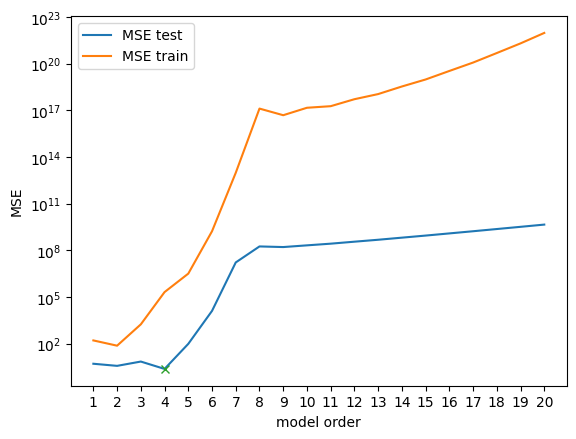

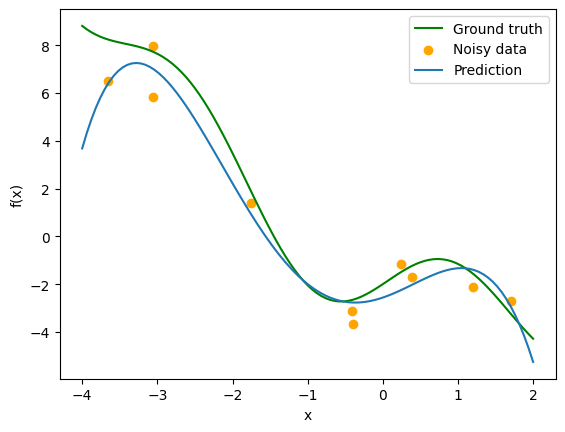

In [49]:
##### DO NOT CHANGE #####
M = 20  # train polynomials up to order M
models = np.arange(1, M+1)
k = 10  # number of partitions, choose from 2 ... 10
MSEs_test = []
MSEs_train = []

for m in models:
    mse_test, mse_train = k_fold_cv(x_data, y_data, m, k)
    MSEs_test.append(mse_test)
    MSEs_train.append(mse_train)
    
m_star_cross = models[np.argmin(MSEs_test)]
print("Best model complexity:", m_star_cross)
print("MSE:", np.min(MSEs_test))
plt.semilogy(models, MSEs_test, label="MSE test")
plt.semilogy(models, MSEs_train, label="MSE train")
plt.semilogy(m_star_cross, np.min(MSEs_test), "x")
plt.xticks(models)
plt.xlabel("model order")
plt.ylabel("MSE")
plt.legend()

p_cv = np.polyfit(x_data, y_data, m_star_cross)
y_cv = np.polyval(p_cv, x)

plt.figure()
plt.plot(x, y_gt, color='g', label="Ground truth")
plt.scatter(x_data, y_data, label="Noisy data", color="orange")
plt.plot(x, y_cv, label="Prediction")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

##### DO NOT CHANGE #####

### Task 1.4: Partition Sizes (1 Point)
Run the next cell to repeat k-fold cross-validation for different numbers of partitions. The plot shows the standard deviation of the train and validation MSE over repeated random partitions.


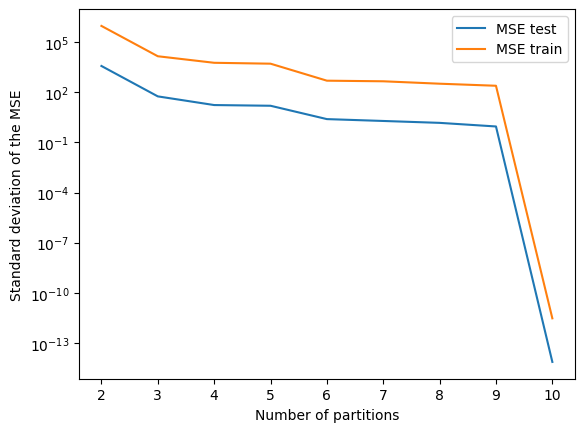

In [50]:
##### DO NOT CHANGE #####
m = 3  # try different model orders
partitions = np.arange(2, 10+1)
MSEs_test_list = []
MSEs_train_list = []
MSEs_test_mean = []
MSEs_train_mean = []
MSEs_test_std = []
MSEs_train_std = []

# for different partition sizes, run k-fold cross validation 100 times
# and record the mean and standard deviation of
# the MSE of the train and test set
for k in partitions:
    for i in range(100):
        mse_test_i, mse_train_i = k_fold_cv(x_data, y_data, m, k)
        MSEs_test_list.append(mse_test_i)
        MSEs_train_list.append(mse_train_i)
    MSEs_test_mean.append(np.mean(MSEs_test_list))
    MSEs_train_mean.append(np.mean(MSEs_train_list))
    MSEs_test_std.append(np.std(MSEs_test_list))
    MSEs_train_std.append(np.std(MSEs_train_list))
    MSEs_test_list = []
    MSEs_train_list = []
    
MSEs_test_mean = np.hstack(MSEs_test_mean)
MSEs_train_mean = np.hstack(MSEs_train_mean)
MSEs_test_std = np.hstack(MSEs_test_std)
MSEs_train_std = np.hstack(MSEs_train_std)
    
plt.semilogy(partitions, MSEs_test_std, label="MSE test")
plt.semilogy(partitions, MSEs_train_std, label="MSE train")

plt.xticks(partitions)
plt.xlabel("Number of partitions")
plt.ylabel("Standard deviation of the MSE")
plt.legend()

##### DO NOT CHANGE #####

Based on the visualization above, what is the main effect of increasing the number of folds (i.e., partitions) in this experiment?

- a) The cross-validation MSE estimate becomes more variable because each fold contains more validation points.
- b) The cross-validation MSE estimate becomes less variable because we average over more folds; for leave-one-out, the random order no longer changes the folds.
- c) The number of folds has no effect because the same polynomial degree is used in every run.
- d) Increasing the number of folds always makes the selected model equal to the true data-generating function.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_1_4` variable.


In [51]:
answer_1_4 = "b"

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_4 - possible points: 1

assert answer_1_4 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

## Exercise 2: Bayesian Linear Regression (7 Points)

While model selection allows us to choose the optimal model class for a given task, it does not account for the fact that a dataset of limited size provides only limited information about the true function.
Bayesian methods can express epistemic uncertainty to model this reality.

Bayesian methods treat the model's weights as random variables. They require use to specify two probability distributions: A prior distribution over weights $p(\boldsymbol{w})$ and a data likelihood $p(\boldsymbol{y} \mid X, \boldsymbol{w})$. For Bayesian Linear Regression (BLR), we use a Gaussian prior with prior precision $\lambda$

$$
    p(\boldsymbol{w}) = \mathcal{N}(\boldsymbol{w} \mid \boldsymbol{0}, \lambda^{-1} I)
$$

and a Gaussian likelihood with fixed variance $\sigma_y^2$

$$
    p(\boldsymbol{y} \mid X, \boldsymbol{w}) = \mathcal{N}(\boldsymbol{y} \mid \Phi \boldsymbol{w}, \sigma_y^2 I),
$$

where $\Phi$ is the (polynomial) feature matrix.
For this specific setup, the posterior distribution $p(\boldsymbol{w} \mid X, \boldsymbol{y})$ is also Gaussian with mean and variance that we can compute in closed form.

The next cell sets up some utility functions and variables.


In [54]:
##### DO NOT CHANGE #####
def polynomial_feature_matrix(x_values: np.ndarray, degree: int) -> np.ndarray:
    """
    Create polynomial features [1, x, x^2, ..., x^degree].

    :param x_values: input values, shape [N]
    :param degree: polynomial degree
    :return: feature matrix, shape [N, degree + 1]
    """
    x_values = np.asarray(x_values).reshape(-1)
    return np.column_stack([x_values ** i for i in range(degree + 1)])

def blr_posterior(phi: np.ndarray, y: np.ndarray, noise_variance: float, prior_lambda: float):
    """
    Compute the posterior distribution over the weights of a Bayesian linear regression model with Gaussian likelihood and Gaussian prior.
    :param phi: feature matrix, shape [N, D]
    :param y: target values, shape [N]
    :param noise_variance: variance of the Gaussian likelihood
    :param prior_lambda: precision (inverse variance) of the Gaussian prior
    :return: mean and precision of the posterior distribution over weights
    """
    precision = phi.T @ phi / noise_variance + prior_lambda * np.eye(phi.shape[1])
    mean = np.linalg.solve(precision * noise_variance, phi.T @ y)
    return mean, precision

prior_lambda = 1.0
noise_variance = 1.0
blr_degrees = np.arange(0, 9)

##### DO NOT CHANGE #####

### Task 2.1: Sequential Bayes (3 Points)

We typically assume the prior distribution to be a simple diagonal Gaussian with fixed precision $\lambda$.
However, this is not necessary: We can use any prior distribution. 
As long as the prior is Gaussian, we will still get a Gaussian posterior distribution in closed form.
In general, if the prior is $\mathcal{N}(\mu_0, \Sigma_0)$, the posterior $\mathcal{N}(\mu_w, \Sigma_w)$ is given by
\begin{align*}
    \Sigma_w &= (\Sigma_0^{-1} + \sigma_y^{-2} \Phi^T \Phi)^{-1} \\
    \mu_w &= \Sigma_w \big( \Sigma_0^{-1} \mu_0 + \sigma_y^{-2} \Phi^T y \big)
\end{align*}
These equations become a lot nicer if we instead work with precision matrices $\Lambda = \Sigma^{-1}$ instead of covariance matrices $\Sigma$:
\begin{align*}
    \Lambda_w &= \Lambda_0 + \sigma_y^{-2} \Phi^T \Phi \\
    \mu_w &= \Lambda_w^{-1} \big( \Lambda_0 \mu_0 + \sigma_y^{-2} \Phi^T y \big)
\end{align*}
In the following, we'll only work with precision matrices.

Now assume that we are given two datasets $D_1$ and $D_2$ from the same data generating process.
Both together are identically and independently distributed.
We can then decompose the parameter posterior:
\begin{align*}
p(w \mid D_1, D_2) &\propto p(D_1, D_2 \mid w) \; p(w) \\
&\propto p(D_2 \mid w) \; \underbrace{p(D_1 \mid w) \; p(w)}_{p'(w)} \\
&\propto p(D_2 \mid w) \; p'(w)
\end{align*}
So if we already know the posterior with respect to $D_1$ and get new data $D_2$, we can just treat the old posterior as a prior $p'(w) \propto p(w \mid D_1) p(w)$ and only need to calculate the likelihood of the new data!

*(Note: We are always using proportionality $\propto$ instead of equality as all of these distributions are, out of convenience, unnormalized.)*

This sequentiality of Bayes' rule allows us to do *continual learning*: When we get new data, we do not need to re-train on all available data, but we can just re-use our previous parameter posterior and update it with only the new data.

**Your Task:**
You'll implement a fully online version of BLR.
At iteration $i$, you receive a single new data point $\boldsymbol{x}^{(i)} \in \mathbb{R}^D, y^{(i)} \in \mathbb{R}$ and the previous posterior mean $\boldsymbol{\mu}_w^{(i-1)}$ and posterior precision $\Lambda_w^{(i-1)}$. You need to compute the new posterior mean $\boldsymbol{\mu}_w^{(i)}$ and posterior precision $\Lambda_w^{(i)}$.
We'll use the prior at $i=0$:
\begin{align*}
\boldsymbol{\mu}_w^{(0)} &= 0 \\
\Lambda_w^{(0)} &= \lambda I
\end{align*}

**Hints:**
- Previously, the prior was $\mathcal{N}(0, \gamma^{-1} I)$. Now the prior in each step is given by the old posterior $\mathcal{N}\left(\mu_{w}^{(i-1)}, \big(\Lambda_w^{(i-1)}\big)^{-1}\right)$. Substitute the prior in the above equations to get the sequential update rule.
- Adapt the matrix terms $\Phi^T \Phi$ and $\Phi^T \boldsymbol{y}$, which assume a batch of data of shape $\Phi \in \mathbb{R}^{N \times D}, \boldsymbol{y} \in \mathbb{R}^N$, to a single data point $\Phi(\boldsymbol{x}) \in \mathbb{R}^D, y \in \mathbb{R}$.

In [56]:
def update_blr_posterior(phi: np.ndarray, y: np.ndarray, prev_mean: np.ndarray, prev_precision: np.ndarray, noise_variance: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the posterior over weights in Bayesian Linear Regression.

    :param Phi: features, shape [D]
    :param y: target, scalar
    :param prev_mean: previous posterior mean, shape [D]
    :param prev_precision: previous posterior precision, shape [D, D]
    :param noise_variance: sigma_y^2, variance of the Gaussian likelihood, scalar
    :return: new posterior mean, shape [D], and new posterior precision, shape [D, D]
    """


    # TODO implement the sequential posterior update for a single data point
    # Use np.linalg.solve for the inverse. You should only need a single matrix inversion!
    new_precision = None
    new_mean = None
    # YOUR CODE HERE
    # previous posterior is 0 initially
    # posterior precision is lambda * I 
    posterior = blr_posterior(phi, y, noise_variance, prev_precision)
    posterior_mean = np.linalg.solve(precision * noise_variance, phi.T @ y)
    # prior_mean = 0
    # prior_precision = gamma * I
    # use old posterior as the new prior
    new_prior = posterior / likelihood

    
    new_precision = posterior[1]
    new_mean = posterior[0]
    
    return new_mean, new_precision

The next cell executes some tests on your function and visualizes the resulting posterior for linear features.
It also shows you the posterior that you get using the non-sequential formulas from the lecture.
If you did everything right, these two should match perfectly!

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_1 - possible points: 3

# Some sample inputs
phi_test = polynomial_feature_matrix(x_data, degree=1)

posterior_mean = np.zeros(phi_test.shape[1])
posterior_precision = prior_lambda * np.eye(phi_test.shape[1])
for i in range(phi_test.shape[0]):
    posterior_mean, posterior_precision = update_blr_posterior(phi_test[i], y_data[i], posterior_mean, posterior_precision, noise_variance)

assert posterior_mean is not None
assert posterior_precision is not None
assert posterior_mean.shape == (phi_test.shape[1],)
assert posterior_precision.shape == (phi_test.shape[1], phi_test.shape[1])

# the posterior precision is always symmetric and positive definite
assert np.allclose(posterior_precision, posterior_precision.T)
assert np.all(np.diag(posterior_precision) > 0.0)

# we can visually verify that the sequential update yields the same posterior as the non-sequential version
def plot_posterior_ellipse(mean, precision, color, label, linestyle="-"):
    from matplotlib.patches import Ellipse

    n_std = 2.0

    # this computes and plots an ellipse that sits at 2 standard deviations
    cov = np.linalg.inv(precision)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, facecolor='none', lw=2, linestyle=linestyle)
    plt.gca().add_patch(ellipse)
    plt.scatter(*mean, color=color, marker='x', s=100, label=label)

non_sequential_mean, non_sequential_precision = blr_posterior(phi_test, y_data, noise_variance, prior_lambda)
plot_posterior_ellipse(non_sequential_mean, non_sequential_precision, "darkblue", "Non-Sequential Posterior", "-")

plot_posterior_ellipse(posterior_mean, posterior_precision, "darkorange", "Sequential Posterior", "--")

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.show()



##### DO NOT CHANGE #####

### Task 2.2: Predictive Distribution (2 Points)

For a query input $\boldsymbol{x}_*$ with feature vector $\boldsymbol{\phi}(\boldsymbol{x}_*)$, the posterior predictive distribution is obtained by integrating out the posterior over weights:

$$
p(y_* \mid \boldsymbol{x}_*, X, \boldsymbol{y}) = \int p(y_* \mid \boldsymbol{w}, \boldsymbol{x}_*) \; p(\boldsymbol{w} \mid X, \boldsymbol{y}) \, d\boldsymbol{w}.
$$

For Bayesian linear regression, the posterior predictive distribution is Gaussian with (scalar) mean $\mu(\boldsymbol{x}_*)$ and (scalar) variance $\sigma^2(\boldsymbol{x}_*)$:
\begin{align}
    \mu(\boldsymbol{x}_*) &= \Phi(\boldsymbol{x}_*) (\boldsymbol{\Phi}^T \boldsymbol{\Phi} + \sigma_y^2 \lambda I)^{-1} \boldsymbol{\Phi}^T y\\
    \sigma^2(\boldsymbol{x}_*) &= \sigma_y^2 \left(1 + \boldsymbol{\phi}(\boldsymbol{x}_*)^T (\Phi^T\Phi + \sigma_y^2 \lambda I)^{-1} \boldsymbol{\phi}(\boldsymbol{x}_*)\right)
\end{align}

These equations assume access to all trainin data $X, \boldsymbol{y}$.
However, they actually only depend on the posterior mean $\boldsymbol{\mu}_w$ and posterior precision $\Lambda_w$ (see task 2.1 for their definition).
Implement the (batched) posterior predictive distribution given posterior mean and precision in `blr_predictive_distribution`.
We recommend to first derive the equations using math notation before implementing them in Python.


In [ ]:
def blr_predictive_distribution(Phi_query: np.ndarray, posterior_mean: np.ndarray, posterior_precision: np.ndarray, noise_variance: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the BLR predictive distribution for query features.

    :param Phi_query: query feature matrix, shape [N_q, D]
    :param posterior_mean: posterior mean over weights, shape [D]
    :param posterior_precision: posterior precision (inverse covariance) over weights, shape [D, D]
    :param noise_variance: sigma_y^2, variance of the Gaussian likelihood, scalar
    :return: predictive mean and variance, both shape [N_q]
    """

    # TODO Compute the posterior predictive distribution
    mean_y = None
    var_y = None
    # YOUR CODE HERE
    raise NotImplementedError()

    return mean_y, var_y


The next cell executes some tests and plots the posterior predictive distribution.

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_2 - possible points: 2

# Useful asserts
phi_plot_test = polynomial_feature_matrix(x, degree=1)
pred_mean, pred_var = blr_predictive_distribution(phi_plot_test, posterior_mean, posterior_precision, noise_variance)

assert pred_mean is not None
assert pred_var is not None
assert pred_mean.shape == x.shape
assert pred_var.shape == x.shape
assert np.all(np.isfinite(pred_mean))
assert np.all(np.isfinite(pred_var))
assert np.all(pred_var >= noise_variance)

plt.fill_between(x, pred_mean - 2 * pred_var, pred_mean + 2 * pred_var, alpha=0.3)
plt.plot(x, pred_mean, label="MAP")
plt.scatter(x_data, y_data, color="black", marker="x", label="Training Data")
plt.legend()
plt.show()



##### DO NOT CHANGE #####

### OOD Robustness Intuition

Instead of only plotting the selected model inside the training range, let us look at extrapolation. In the following, we'll switch to polynomial features of degree 8 to model more flexible functions. A point-estimate high-degree polynomial can make very confident-looking predictions far away from the data, while BLR can express increasing predictive uncertainty outside the observed region.


In [ ]:
##### DO NOT CHANGE #####
x_ood = np.linspace(np.min(x_data) - 3.0, np.max(x_data) + 3.0, 300)
y_ood_gt = target_function(x_ood)

# BLR predictive distribution for a fixed polynomial degree.
blr_ood_degree = 8
Phi_train_blr = polynomial_feature_matrix(x_data, blr_ood_degree)
ood_posterior_mean, ood_posterior_cov = blr_posterior(
    Phi_train_blr,
    y_data,
    prior_lambda,
    noise_variance,
)
Phi_ood_blr = polynomial_feature_matrix(x_ood, blr_ood_degree)
pred_mean_blr, pred_var_blr = blr_predictive_distribution(
    Phi_ood_blr,
    ood_posterior_mean,
    ood_posterior_cov,
    noise_variance,
)
pred_std_blr = np.sqrt(np.maximum(pred_var_blr, 0.0))

# A high-degree point-estimate polynomial for comparison.
overfit_degree = int(np.max(blr_degrees))
p_overfit = np.polyfit(x_data, y_data, overfit_degree)
y_overfit = np.polyval(p_overfit, x_ood)

plt.figure(figsize=(9, 5))
plt.plot(x_ood, y_ood_gt, color="green", label="Ground truth")
plt.scatter(x_data, y_data, color="orange", label="Noisy training data", zorder=3)
plt.plot(x_ood, y_overfit, color="red", linestyle="--", label=f"Point estimate, degree {overfit_degree}")
plt.plot(x_ood, pred_mean_blr, color="blue", label=f"BLR mean, degree {blr_ood_degree}")
plt.fill_between(
    x_ood,
    pred_mean_blr - 2.0 * pred_std_blr,
    pred_mean_blr + 2.0 * pred_std_blr,
    color="blue",
    alpha=0.2,
    label="BLR 95% uncertainty interval",
)
plt.axvspan(np.min(x_data), np.max(x_data), color="gray", alpha=0.1, label="Observed input range")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Out-of-Distribution Extrapolation")
plt.ylim(np.percentile(y_ood_gt, 1) - 20, np.percentile(y_ood_gt, 99) + 20)
plt.legend()
plt.show()


##### DO NOT CHANGE #####

### Task 2.3: OOD Prediction Quality (1 Point)
Look at the out-of-distribution (OOD) plot above. What is the most appropriate interpretation of the predictions far away from the observed input range, and what would be a sensible way to improve them?

- a) The BLR mean is guaranteed to be close to the true function outside the training range because BLR is Bayesian; no improvement is needed.
- b) The high-degree point-estimate polynomial is more trustworthy outside the training range because it fits the training data more flexibly; increasing the degree further should improve the accuracy of OOD predictions.
- c) BLR's OOD predictions should be treated cautiously; BLR can express increased uncertainty, and OOD behavior can be improved by adding data in the relevant input region or by choosing a more suitable prior/model class.
- d) The training MSE is indicative of the model's OOD performance, so lowering the training MSE is sufficient to improve OOD predictions.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_2_3` variable.


In [ ]:
answer_2_3 = None
# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_3 - possible points: 1

assert answer_2_3 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

### Task 2.4: Bayesian Linear Regression vs. Ridge Regression (1 Point)

Which statement best describes the difference between Bayesian Linear Regression and Ridge Regression?

- a) BLR only returns one optimal weight vector, while Ridge Regression returns a full posterior distribution.
- b) BLR returns a posterior distribution over weights and can express predictive uncertainty, while Ridge Regression returns a point estimate.
- c) BLR does not need a likelihood model, while Ridge Regression does.
- d) BLR cannot use polynomial features, while Ridge Regression can.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_2_4` variable.


In [ ]:
answer_2_4 = None
# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_4 - possible points: 1

assert answer_2_4 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

## Exercise 3: Gaussian Processes (5 Points)
In this exercise, we kernelize the Bayesian Linear Regression idea and work with Gaussian Processes (GPs). We use the same one-dimensional toy dataset as above.

### Task 3.1: Gaussian Kernel (2 Points)
For two input points $\boldsymbol{x}, \boldsymbol{x}' \in \mathbb{R}^d$, the Gaussian kernel is

$$
k(\boldsymbol{x}, \boldsymbol{x}') = \lambda^{-1} \exp\left(-\frac{\lVert \boldsymbol{x} - \boldsymbol{x}' \rVert^2}{2\sigma^2}\right).
$$

Implement `gaussian_kernel` so that it computes all pairwise kernel values between a batch `x` with shape `[N_1, d]` and a batch `x_prime` with shape `[N_2, d]`. The returned array should have shape `[N_1, N_2]`.

**Hints:**
- The implementation already resizes one-dimensional features without an explicit feature dimension (i.e., shape `[N]`) by unsqueezing the feature dimension (i.e., shape `[N, 1]`).
- Use NumPy broadcasting instead of explicit Python loops.


In [ ]:
def gaussian_kernel(x: np.ndarray, x_prime: np.ndarray, lam: float, sigma: float) -> np.ndarray:
    """
    Compute the Gaussian kernel for all pairs of rows in x and x_prime.

    :param x: first input batch, shape [N_1, d] or [N_1]
    :param x_prime: second input batch, shape [N_2, d] or [N_2]
    :param lam: prior precision parameter, scalar
    :param sigma: kernel bandwidth, scalar
    :return: kernel matrix, shape [N_1, N_2]
    """
    x = np.asarray(x)
    x_prime = np.asarray(x_prime)

    if x.ndim == 1:
        x = x.reshape((-1, 1))

    if x_prime.ndim == 1:
        x_prime = x_prime.reshape((-1, 1))


    # TODO Compute the pairwise Gaussian kernel between x and x_prime
    kernel = None
    # YOUR CODE HERE
    raise NotImplementedError()

    assert kernel.shape == (x.shape[0], x_prime.shape[0])
    return kernel


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_1 - possible points: 2

# Useful asserts
kernel_check = gaussian_kernel(np.array([-1.0, 0.0, 1.0]), np.array([0.0, 1.0]), lam=2.0, sigma=0.5)
assert kernel_check is not None
assert kernel_check.shape == (3, 2)
assert np.all(np.isfinite(kernel_check))
assert np.all(kernel_check >= 0.0)
assert np.all(kernel_check <= 0.5)

kernel_matrix_check = gaussian_kernel(np.array([-1.0, 0.0, 1.0]), np.array([-1.0, 0.0, 1.0]), lam=2.0, sigma=0.5)
assert np.allclose(kernel_matrix_check, kernel_matrix_check.T)
assert np.allclose(np.diag(kernel_matrix_check), 0.5)



##### DO NOT CHANGE #####

Using `gaussian_kernel`, we can compute the kernel matrix of the training inputs. You do not need to implement anything in the next cell.


In [ ]:
##### DO NOT CHANGE #####
def gaussian_kernel_matrix(X: np.ndarray, lam: float, sigma: float) -> np.ndarray:
    """
    Compute the Gaussian kernel matrix for the training inputs.

    :param X: training inputs, shape [N, d] or [N]
    :param lam: prior precision parameter, scalar
    :param sigma: kernel bandwidth, scalar
    :return: kernel matrix, shape [N, N]
    """
    return gaussian_kernel(x=X, x_prime=X, lam=lam, sigma=sigma)


##### DO NOT CHANGE #####

### Task 3.2: Predictive Distribution for GPs (2 Points)
For query inputs $X_*$, let $K$ be the training kernel matrix and $K_* = k(X, X_*)$ the matrix of kernel values between training and query inputs. The GP predictive mean and marginal predictive variances are

$$
\boldsymbol{\mu}_* = K_*^T (K + \sigma_y^2 I)^{-1} \boldsymbol{y},
$$

$$
\mathrm{diag}(\Sigma_*) = \sigma_y^2 + \mathrm{diag}(k(X_*, X_*)) - \mathrm{diag}(K_*^T (K + \sigma_y^2 I)^{-1} K_*).
$$

Implement `gp_predictive_distribution`. Use the global `noise_variance` for $\sigma_y^2$ and use `np.linalg.solve` instead of an explicit inverse.

**Hints:**
- Use `gaussian_kernel` and `gaussian_kernel_matrix`.
- Return one mean and one marginal variance per query input.
- Do not use explicit Python loops.


In [ ]:
def gp_predictive_distribution(x: np.ndarray, y: np.ndarray, X: np.ndarray, lam: float, sigma: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the GP predictive distribution for query inputs.

    :param x: query inputs, shape [N_q, d] or [N_q]
    :param y: training targets, shape [N] or [N, 1]
    :param X: training inputs, shape [N, d] or [N]
    :param lam: prior precision parameter, scalar
    :param sigma: kernel bandwidth, scalar
    :return: predictive mean and marginal variance, both shape [N_q]
    """
    x = np.asarray(x)
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    if x.ndim == 1:
        x = x.reshape((-1, 1))
    if X.ndim == 1:
        X = X.reshape((-1, 1))

    # TODO Compute the GP predictive distribution using the kernel functions defined above
    mean_x = None
    var_x = None
    # YOUR CODE HERE
    raise NotImplementedError()

    assert mean_x.shape == (x.shape[0],)
    assert var_x.shape == (x.shape[0],)
    return mean_x, var_x


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_2 - possible points: 2

# Useful asserts
X_gp_check = np.array([-1.0, 0.0, 1.0])
y_gp_check = np.array([0.5, -0.2, 0.7])
x_gp_check = np.array([-0.5, 0.5])
gp_mean_check, gp_var_check = gp_predictive_distribution(x_gp_check, y_gp_check, X_gp_check, lam=1.5, sigma=0.8)

assert gp_mean_check is not None
assert gp_var_check is not None
assert gp_mean_check.shape == x_gp_check.shape
assert gp_var_check.shape == x_gp_check.shape
assert np.all(np.isfinite(gp_mean_check))
assert np.all(np.isfinite(gp_var_check))
assert np.all(gp_var_check >= 0.0)



##### DO NOT CHANGE #####

The next cell visualizes how the GP predictive distribution changes for different values of $\lambda$ and $\sigma$.


In [ ]:
##### DO NOT CHANGE #####
X_gp_train = x_data.reshape(-1, 1)
y_gp_train = y_data
X_gp_plot = x.reshape(-1, 1)
y_gp_plot = y_gt

lambdas = [1e-3, 1.0, 10.0]
feature_sigmas = [0.2, 1.0, 3.0]

pred_means = []
pred_vars = []
labels = []
for lam in lambdas:
    for feature_sigma in feature_sigmas:
        pred_mean, pred_var = gp_predictive_distribution(
            x=X_gp_plot,
            y=y_gp_train,
            X=X_gp_train,
            lam=lam,
            sigma=feature_sigma,
        )
        pred_means.append(pred_mean)
        pred_vars.append(np.maximum(pred_var, 0.0))
        labels.append(f"$\lambda$ = {lam}, $\sigma$ = {feature_sigma}")

fig, axes = plt.subplots(
    nrows=len(lambdas),
    ncols=len(feature_sigmas),
    sharex=True,
    figsize=(len(feature_sigmas) * 4, len(lambdas) * 3),
    squeeze=False,
)
for i, (pred_mean, pred_var, label) in enumerate(zip(pred_means, pred_vars, labels)):
    ax = axes[i // len(feature_sigmas), i % len(feature_sigmas)]
    pred_std = np.sqrt(pred_var)
    ax.plot(x, pred_mean, color="blue", label="GP mean")
    ax.fill_between(x, pred_mean - 2.0 * pred_std, pred_mean + 2.0 * pred_std, alpha=0.2, color="blue")
    ax.scatter(x_data, y_data, color="orange", s=18, label="Noisy data")
    ax.plot(x, y_gp_plot, color="green", linewidth=1.5, label="Ground truth")
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
fig.tight_layout(rect=(0, 0, 1, 0.94))


##### DO NOT CHANGE #####

### Task 3.3: Sampling Functions from a GP (1 Point)
For BLR, *function* samples at query inputs can be obtained by sampling weights from the posterior and evaluating the corresponding feature representation. How does the analogous *function* sampling procedure work for GPs?

- a) Sample a separate scalar independently at each query input using only the marginal predictive variance.
- b) Compute the joint GP predictive mean and covariance at the query inputs, then sample a vector of function values from that multivariate Gaussian.
- c) Sample polynomial weights from the BLR posterior and reuse them as GP function values.
- d) Randomly resample training targets and use the nearest training target as the function value.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_3_3` variable.


In [ ]:
answer_3_3 = None
# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_3 - possible points: 1

assert answer_3_3 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####